# 07 — Exploratory analysis: the questions behind the Democratic Funnel

**Visualisation Notebook**

**The Democratic Funnel** · Team UL · DIRISA Student Datathon Challenge 2026

# 1. Introduction

**Purpose.** This notebook explores how many South Africans register to vote, how many of those registered voters actually cast a ballot, where turnout is lowest, which measurable municipal characteristics go together with lower turnout, and how participation differs by age group.

**Reads:** `data/processed/master.csv` (and, if present, `data/interim/boundaries.gpkg`,
`data/interim/atlas_registration_activity_2016.csv`)  **Writes:** charts to `reports/figures/`

Every municipality loses people at two points on the way to the ballot box:

```
Adults who may vote  →  People who registered  →  People who voted
        E                        R                       V
            registration leak         turnout leak
```

- **Registration rate** `r = R / E` · **Turnout** `t = V / R` · **Real participation** `p = r × t = V / E`

**Analytical questions.** The nine  questions tells a complete story, from *how many* to *where* to *why* to *who*

| # | Question | |
|---|---|---|
| Q1 | What is the trend between registration and turnout rate? (2011-2026) |  |
| Q2 | How does turnout differ between provinces? ||
| Q3 | Which municipalities have the lowest turnout over the years? ||
| Q4 | Which age group has the lowest electoral participation? | |
| Q5 | Which factors are linked to low turnout? | |
| Q6 | Does low turnout cluster geographically? | |
| Q7 | How does population density affect low turnout? | |
| Q8 | Where should effort go before 4 November 2026? | |

## 0. Setup

In [ ]:
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Thato20-M/democratic-funnel.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_DIR = Path("/content/democratic-funnel")
    url = REPO_URL
    try:
        from google.colab import userdata
        url = REPO_URL.replace("https://", f"https://{userdata.get('GITHUB_TOKEN')}@")
    except Exception:
        print("No GITHUB_TOKEN in Colab Secrets - cloning will fail for the private repo")
    if REPO_DIR.exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "-q"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", url, str(REPO_DIR)], check=True)
else:
    REPO_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "src" / "config.py").exists())

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repo:", REPO_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo: /content/democratic-funnel


In [ ]:
# ---------------------------------------------------------------
# Libraries and global settings
# ---------------------------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plotly is optional: interactive charts are shown only if it is installed
try:
    import plotly.express as px
    PLOTLY = True
except ImportError:
    PLOTLY = False

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# One consistent, colour-blind-friendly palette used throughout (DIRISA: limited, consistent colours)
MAIN      = "#1F4E79"   # main series (navy)
SECOND    = "#E67E22"   # second series (orange)
HIGHLIGHT = "#C0392B"   # key finding (red) - always paired with a text label, never colour alone
MUTED     = "#B8C0CC"   # context / de-emphasised

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid.axis": "y",   # horizontal gridlines only; horizontal bar charts switch to vertical ones
})

def add_subtitle(ax, text):
    # Grey subtitle under the (left-aligned) chart title: context, units and denominator
    ax.text(0, 1.02, text, transform=ax.transAxes, fontsize=9.5, color="#555555", va="bottom")

DATA_PATH = Path("master.csv")   # change this if the file lives elsewhere
print("Plotly available:", PLOTLY)

Plotly available: True


In [ ]:
from src import config
from src.config import INTERIM, PROCESSED, FIGURES

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)

config.make_dirs(); config.set_seed()
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)
print(config.describe())

Environment: Colab
Repo root:   /content/democratic-funnel
Work root:   /content/drive/MyDrive/DIRISA_SDC


### House style: one set of colours and words, used everywhere

The same colours mean the same thing in this notebook, on the slides and in the dashboard.

| Colour | Means |
|---|---|
| **Blue** | registration (the roll) |
| **Amber** | turnout (voting) |
| **Crimson** | both problems |
| **Green** | healthy |
| **Navy** | national figures |

The four group colours were checked for colour-blind readers as a set (worst pair ΔE 9.9 under colour-blind
simulation; target ≥ 8). Crimson and green are also far apart in lightness, so "both problems" and "healthy"
never look alike. Amber and light green are pale on white, so **every chart that uses them also has written
labels** — colour never carries meaning on its own.

`LABELS` turns column names into plain English, so nothing like `leak_turn` appears on a chart.

In [ ]:
# --- colours ---------------------------------------------------------------------------
BLUE, AMBER, CRIMSON, GREEN, NAVY = "#2a78d6", "#eda100", "#a3143a", "#7bc586", "#1b2f5b"
NAVY_LIGHT = "#b7c3dc"                      # context lines (e.g. individual provinces)
INK, INK2, GRID, SURFACE = "#0b0b0b", "#4a4a47", "#e4e3de", "#ffffff"

GROUPS = ["Low registration", "Low turnout", "Both low", "Healthy"]
GROUP_COLOURS = {"Low registration": BLUE, "Low turnout": AMBER, "Both low": CRIMSON, "Healthy": GREEN}
WHAT_TO_SEND = {"Low registration": "registration drive, ID and address help",
                "Low turnout": "voter education and mobilisation",
                "Both low": "both - first priority",
                "Healthy": "nothing urgent"}

# --- plain-English names for every column that appears on a chart or table -------------
LABELS = {
    "r": "Registration rate", "t": "Turnout", "p": "Real participation",
    "leak_reg": "Registration vs typical municipality", "leak_turn": "Turnout vs typical municipality",
    "registered": "Registered voters", "votes_cast": "Votes cast", "eligible_adults": "Adults who may vote",
    "eligible_youth": "Young adults who may vote (18-29)", "registered_youth": "Registered young adults (18-29)",
    "youth_r": "Youth registration rate (18-29)", "adult_r": "Registration rate, all adults",
    "higher_ed_rate": "Adults with higher education", "piped_water_rate": "Households with piped water",
    "electricity_rate": "Households with electricity", "refuse_removal_rate": "Households with refuse removal",
    "log_density": "Population density (log)", "pop_density": "People per km²", "area_km2": "Area (km²)",
    "spatial_lag_turnout": "Neighbours' turnout", "muni_name": "Municipality", "province": "Province",
    "muni_code": "Code", "group": "Problem group",
}

plt.rcParams.update({                         # large text: these charts go on slides
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.titlelocation": "center", "axes.titlepad": 12, "axes.labelsize": 11,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "grid.color": GRID, "grid.linewidth": 0.7, "legend.frameon": False, "legend.fontsize": 10.5,
    "font.size": 11,
})


def tidy(ax, xgrid=False, ygrid=True):
    """Recessive axes: no box, gridlines behind the data only where they help reading."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax


def pct(ax, axis="y"):
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    return ax


def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png", bbox_inches="tight")
    print("saved", name)


def group_of(reg_gap, turn_gap):
    """Below the typical (median) municipality on registration and/or turnout."""
    return pd.Series(np.select([(reg_gap < 0) & (turn_gap < 0), reg_gap < 0, turn_gap < 0],
                               ["Both low", "Low registration", "Low turnout"], "Healthy"),
                     index=reg_gap.index)

## 1. Load and check the data

`master.csv` has one row per municipality per election: 213 municipalities × 4 elections
(2011, 2016, 2021, 2026) = 852 rows. 2026 has registration but no votes yet — that election has not happened.

In [ ]:
master = pd.read_csv(PROCESSED / "master.csv")
assert master.groupby("election")["muni_code"].nunique().to_dict() == {2011: 213, 2016: 213, 2021: 213, 2026: 213}
assert not master.duplicated(["election", "muni_code"]).any()

y21 = master[master["election"] == 2021].copy()
y26 = master[master["election"] == 2026].copy()
held = master[master["election"] < 2026].copy()          # elections that actually happened

missing = master.isna().groupby(master["election"]).sum().T
print("Missing values per column (only columns with any):")
print(missing[missing.sum(axis=1) > 0].to_string())

Missing values per column (only columns with any):
election             2011  2016  2021  2026
valid_votes             0     0     0   213
spoilt                  0     0     0   213
votes_cast              0     0     0   213
turnout                 0     0     0   213
registered_youth      213   213   213     0
t                       0     0     0   213
p                       0     0     0   213
leak_turn               0     0     0   213
t_prev                213     0     0     0
r_prev                213     0     0     0
dt                    213     0     0   213
spatial_lag_turnout     0     0     0   213
spatial_lag_prev      213     0     0     0


In [ ]:
# Use today's municipality names everywhere (some IEC files use older or placeholder names, e.g. "New Municipality")
current_name = y26.set_index("muni_code")["muni_name"]
current_name = current_name.where(~current_name.str.isupper(), current_name.str.title())
for df in (master, y21, y26, held):
    df["muni_name"] = df["muni_code"].map(current_name)

**Every missing value has a reason.** 2026 has no votes, turnout or turnout leak (not held yet). 2011 has no
"previous election" columns. `registered_youth` exists for 2026 only — the IEC publishes registration by
age for the current roll, not for past elections.

##Metric definitions

Every rate in this notebook uses one of these definitions, and every chart names the one it uses.

| Metric | Formula | Denominator |
|---|---|---|
| **Turnout rate (%)** | Votes cast ÷ Registered voters × 100 | People on the voters' roll |
| **Registration rate (%)** | Registered voters ÷ Eligible adults × 100 | Census 2022 citizens aged 18+ |
| **Participation among eligible (%)** | Votes cast ÷ Eligible adults × 100 | Census 2022 citizens aged 18+ |

"Turnout" on its own always means the first definition. National rates are calculated from **summed counts** (total votes ÷ total registered), not by averaging municipal percentages. This way a large metro counts in proportion to its size.

The reusable functions below do all the calculations.

In [ ]:
import numpy as np
import pandas as pd

# Data cleaning pipeline — using 'master' as the base dataset
clean = master.copy()

# (a) Types: election year as int, counts as numeric
clean["election"] = pd.to_numeric(clean["election"], errors="coerce").astype(int)
count_cols = [
    "registered", "votes_cast", "valid_votes", "spoilt",
    "registered_youth", "eligible_adults", "eligible_youth"
]
for c in count_cols:
    clean[c] = pd.to_numeric(clean[c], errors="coerce")

# (b) Text standardization
for c in ["province", "muni_code", "muni_name", "district_code", "muni_category"]:
    clean[c] = clean[c].astype(str).str.strip()

# (c) Title casing municipal names
def tidy_name(name):
    letters = [ch for ch in name if ch.isalpha()]
    mostly_caps = sum(ch.isupper() for ch in letters) > 0.6 * len(letters) if letters else False
    return name.title() if mostly_caps else name

latest_name = clean.sort_values("election").groupby("muni_code")["muni_name"].last().map(tidy_name)
clean["muni_name_raw"] = clean["muni_name"]
clean["muni_name"] = clean["muni_code"].map(latest_name)

# (d) Metadata flags
clean["muni_type"] = clean["muni_category"].map({"A": "Metro", "B": "Local municipality"})
clean["has_votes"] = clean["votes_cast"].notna()
clean["reg_exceeds_eligible"] = clean["registered"] > clean["eligible_adults"]
clean["reapportioned_2011"] = clean["election"].eq(2011)

# (e) Calculate turnout rate
clean["turnout"] = calculate_turnout(clean["votes_cast"].values, clean["registered"].values)

# Summary checks
print(f"Names standardised: {(clean['muni_name'] != clean['muni_name_raw']).sum()} rows changed")
print(f"Codes with one name now: {(clean.groupby('muni_code')['muni_name'].nunique() == 1).all()}")
print(f"Rows flagged registered > eligible: {clean['reg_exceeds_eligible'].sum()}")

# Inspect modified names preview
clean[["election", "muni_code", "muni_name_raw", "muni_name"]][clean["muni_name"] != clean["muni_name_raw"]].head()

Names standardised: 4 rows changed
Codes with one name now: True
Rows flagged registered > eligible: 26


,election,muni_code,muni_name_raw,muni_name
592,2011,NC067,KHâI-MA,Khâi-Ma
593,2016,NC067,KHâI-MA,Khâi-Ma
594,2021,NC067,KHâI-MA,Khâi-Ma
595,2026,NC067,KHâI-MA,Khâi-Ma


In [ ]:
def calculate_turnout(votes, registered):
    # Turnout rate (%) = votes cast / registered voters x 100. Returns NaN when votes/registered are invalid or zero.
    valid_mask = pd.notna(votes) & pd.notna(registered) & (registered > 0)
    return np.divide(votes, registered, out=np.full_like(votes, np.nan, dtype=float), where=valid_mask) * 100

---
# A. Turnout and Registration

## Q1. What is the trend between registration and turnout rate? (2011-2026)

Turnout = votes cast ÷ registered voters, for the ward ballot, added up over all 213 municipalities.

In [ ]:
nat = held.groupby("election")[["registered", "votes_cast"]].sum()
nat.loc[2026, "registered"] = y26["registered"].sum()
nat["turnout"] = nat["votes_cast"] / nat["registered"]
print((nat.assign(registered=lambda d: (d.registered / 1e6).round(2),
                  votes_cast=lambda d: (d.votes_cast / 1e6).round(2),
                  turnout=lambda d: (d.turnout * 100).round(1))
       .rename(columns={"registered": "registered (m)", "votes_cast": "votes cast (m)", "turnout": "turnout %"})
       .to_string()))

          registered (m)  votes cast (m)  turnout %
election                                           
2011               23.62           13.57       57.4
2016               26.33           15.21       57.7
2021               26.20           11.95       45.6
2026               29.23             NaN        NaN


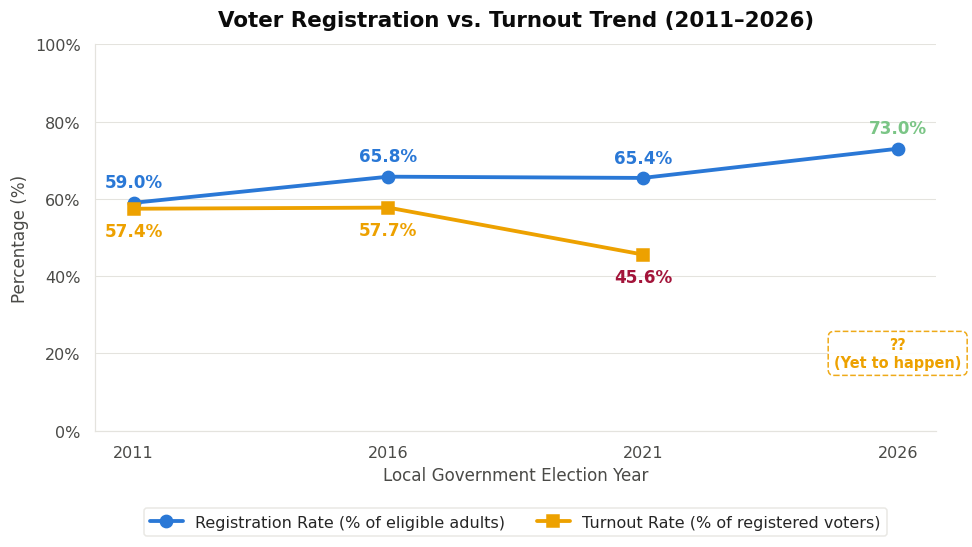

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Aggregate national totals per election year
nat_summary = clean.groupby("election")[["registered", "eligible_adults", "votes_cast"]].sum()

# 2. Compute national percentage rates
nat_summary["reg_rate_%"] = (nat_summary["registered"] / nat_summary["eligible_adults"]) * 100
nat_summary["turnout_%"] = (nat_summary["votes_cast"] / nat_summary["registered"]) * 100

# Exclude 2026 completely from the turnout series so no line is drawn beyond 2021
turnout_held = nat_summary.loc[nat_summary.index < 2026, "turnout_%"]

# 3. Create Chart
fig, ax = plt.subplots(figsize=(9, 5.2))

# Plot Registration Rate (2011–2026)
ax.plot(
    nat_summary.index,
    nat_summary["reg_rate_%"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=BLUE,
    label="Registration Rate (% of eligible adults)",
)

# Plot Turnout Rate ONLY up to 2021
ax.plot(
    turnout_held.index,
    turnout_held,
    marker="s",
    linewidth=2.5,
    markersize=8,
    color=AMBER,
    label="Turnout Rate (% of registered voters)",
)

# Annotate Registration Data Points
for year, rate in zip(nat_summary.index, nat_summary["reg_rate_%"]):
    color = GREEN if year == 2026 else BLUE
    ax.annotate(
        f"{rate:.1f}%",
        (year, rate),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontweight="bold",
        color=color,
    )

# Annotate Turnout Data Points (2011–2021 only)
for year, rate in zip(turnout_held.index, turnout_held):
    color = CRIMSON if year == 2021 else AMBER
    ax.annotate(
        f"{rate:.1f}%",
        (year, rate),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontweight="bold",
        color=color,
    )

# Add "?? (Yet to happen)" placeholder badge for 2026
ax.annotate(
    "??\n(Yet to happen)",
    (2026, 20),
    ha="center",
    va="center",
    fontweight="bold",
    fontsize=9.5,
    color=AMBER,
    bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=AMBER, linestyle="--", alpha=0.9),
)

# Format Axes and Styling
ax.set_ylim(0, 100)
ax.set_xticks(nat_summary.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Local Government Election Year")
ax.set_ylabel("Percentage (%)")
ax.set_title("Voter Registration vs. Turnout Trend (2011–2026)")

# Move legend underneath the plot area centered horizontally
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
    facecolor=SURFACE,
    edgecolor=GRID,
)

tidy(ax)

plt.tight_layout()
plt.show()

**Answer.** The primary trend between registration and turnout is an expanding "turnout leak":
While South Africans are registering to vote at higher rates than ever before, actual participation at the ballot box dropped sharply. The challenge facing electoral participation is not getting eligible citizens registered onto the roll, but motivating registered voters to show up on election day.

#Q2: How does turnout differ between provinces?

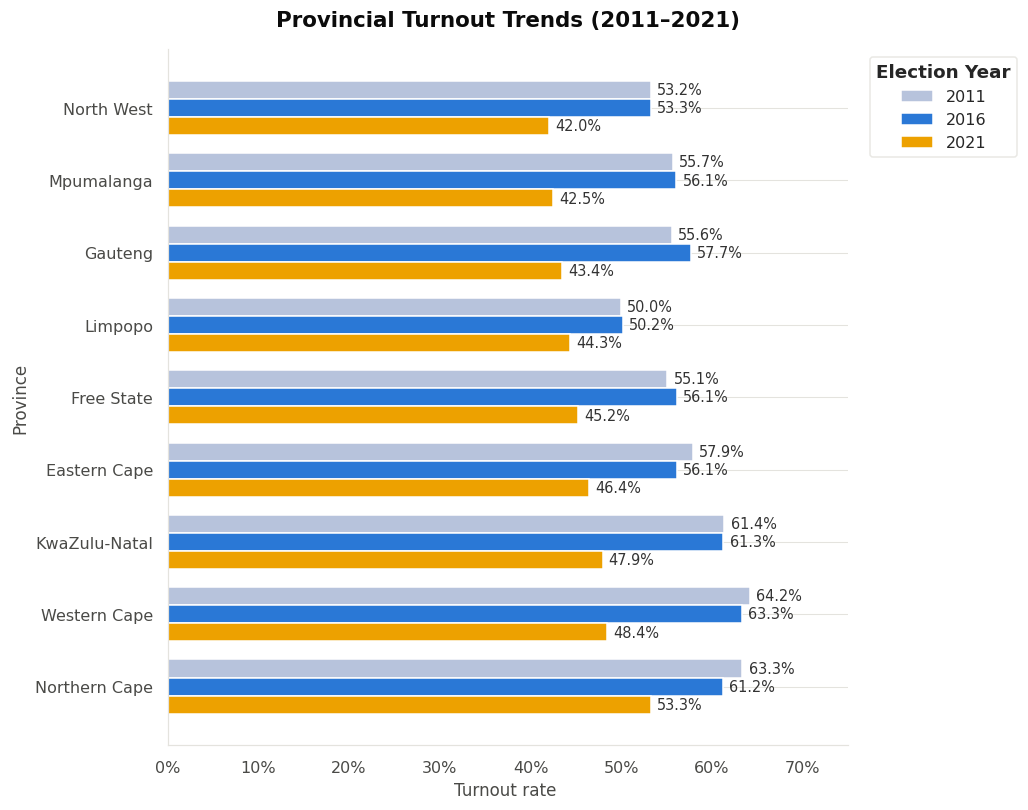

province,2011,2016,2021
Northern Cape,63.3%,61.2%,53.3%
Western Cape,64.2%,63.3%,48.4%
KwaZulu-Natal,61.4%,61.3%,47.9%
Eastern Cape,57.9%,56.1%,46.4%
Free State,55.1%,56.1%,45.2%
Limpopo,50.0%,50.2%,44.3%
Gauteng,55.6%,57.7%,43.4%
Mpumalanga,55.7%,56.1%,42.5%
North West,53.2%,53.3%,42.0%


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from IPython.display import display

# 1. Aggregate provincial totals for 2011, 2016, and 2021
prov_multi = (
    clean[clean["election"].isin([2011, 2016, 2021])]
    .groupby(["province", "election"])[["registered", "votes_cast"]]
    .sum()
)

# 2. Compute turnout percentage and pivot so years become columns
prov_multi["turnout_%"] = (prov_multi["votes_cast"] / prov_multi["registered"]) * 100
prov_pivot = prov_multi["turnout_%"].unstack("election")

# Sort based on 2021 turnout (highest at the top of dataframe, plotted at bottom of chart)
prov_pivot = prov_pivot.sort_values(2021, ascending=False)

# 3. Setup Plot
fig, ax = plt.subplots(figsize=(9.5, 7.5))

y = np.arange(len(prov_pivot))  # the base label locations
height = 0.25                   # the width of each individual bar

# 4. Plot each year as a grouped bar
# (Offsetting y + height plots 2011 at the top of the group, y - height plots 2021 at the bottom)
bars_2011 = ax.barh(y + height, prov_pivot[2011], height, label="2011", color=NAVY_LIGHT)
bars_2016 = ax.barh(y,          prov_pivot[2016], height, label="2016", color=BLUE)
bars_2021 = ax.barh(y - height, prov_pivot[2021], height, label="2021", color=AMBER)

# Add percentage labels outside the ends of the bars
for bars in [bars_2011, bars_2016, bars_2021]:
    ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9.5, color="#333333")

# 5. Formatting
ax.set_yticks(y)
ax.set_yticklabels(prov_pivot.index)
ax.set_xlim(0, 75)  # Extended x-limit to make room for labels
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.grid(False)
ax.grid(axis="x", alpha=0.6)
ax.set_xlabel("Turnout rate ")
ax.set_ylabel("Province")
ax.set_title("Provincial Turnout Trends (2011–2021)", pad=15)

# Add the legend outside to the right
ax.legend(
    title="Election Year",
    title_fontproperties={'weight':'bold'},
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor=SURFACE,
    edgecolor=GRID
)

tidy(ax)
plt.tight_layout()
plt.show()

# 6. Display Summary Table
# Clean up the table index/columns for display
table_df = prov_pivot.copy().reset_index()
table_df.columns.name = None

display(
    table_df.style.format({
        2011: "{:.1f}%",
        2016: "{:.1f}%",
        2021: "{:.1f}%"
    }).hide(axis="index")
)

**Answer** Provincial turnout dropped significantly across every single province between 2016 and 2021, with participation falling by 10 to 14 percentage points nationwide. While the Northern Cape and Western Cape consistently maintained the highest turnout rates across all three election years (hovering around 61% to 64% in 2011/2016 and dropping to 53% and 48% respectively in 2021), provinces like Gauteng and Limpopo recorded the lowest participation, with Gauteng's turnout collapsing to just 43.4% in 2021.

## Q3. Which municipalities have the lowest turnout over the years?

saved q04_lowest_turnout


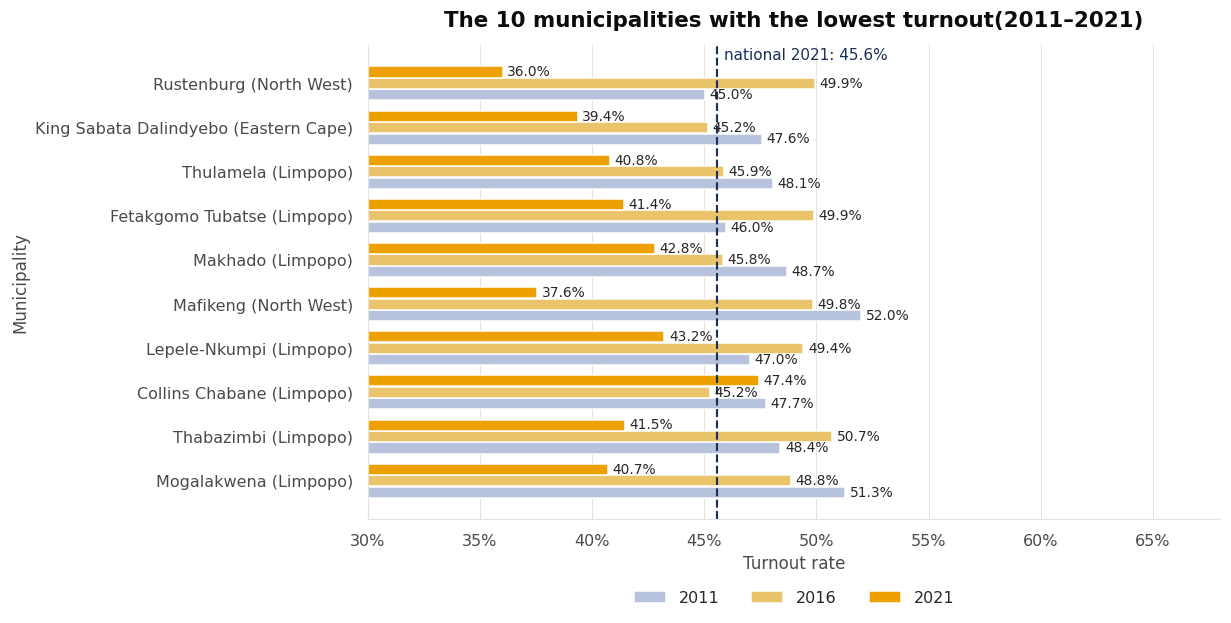

In [ ]:
low10 = tw.nsmallest(10, "Average").iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.6))

for i, (yr, colour, dy) in enumerate([(2011, NAVY_LIGHT, -0.26), (2016, "#e9c46a", 0), (2021, AMBER, 0.26)]):
    # 1. Assign the plotted bars to a variable
    bars = ax.barh(np.arange(10) + dy, low10[yr], height=0.25, color=colour, label=str(yr))

    # 2. Add formatted percentage labels to the bars
    ax.bar_label(bars, labels=[f"{v*100:.1f}%" for v in low10[yr]], padding=3, fontsize=9)

ax.set_yticks(range(10))
ax.set_yticklabels([f"{m} ({p})" for m, p in zip(low10["Municipality"], low10["Province"])])

ax.axvline(nat.loc[2021, "turnout"], color=NAVY, lw=1.4, ls="--")
ax.annotate(f"national 2021: {nat.loc[2021, 'turnout']:.1%}", (nat.loc[2021, "turnout"], 9.55), xytext=(4, 0),
            textcoords="offset points", fontsize=10, color=NAVY)

pct(ax, "x")
tidy(ax, xgrid=True, ygrid=False)

# 3. Increased the upper x-limit from 0.62 to 0.68 to make room for the labels
ax.set_xlim(0.3, 0.68)

ax.set_title("The 10 municipalities with the lowest turnout(2011–2021)")
ax.set_xlabel("Turnout rate")
ax.set_ylabel('Municipality')
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=3)

save(fig, "q04_lowest_turnout")
plt.show()

**Answer.** **Rustenburg (North West)** has the lowest turnout over the years: lowest in 2011 (45.0%) and 2021
(36.0%), and the lowest average across all three elections (43.7%). The lowest average turnout is concentrated in
**Limpopo** (7 of the 10) and **North West**. Six municipalities were in the bottom 20 in **every** election:
Rustenburg, King Sabata Dalindyebo, Thulamela, Fetakgomo Tubatse, Mogalakwena and Thabazimbi.

The biggest **falls** in 2021 were elsewhere — in KwaZulu-Natal and in metros: Mkhambathini (−23.6 points),
Msunduzi, Mbombela, eThekwini and Nelson Mandela Bay (about −18 to −19).

**Careful.** Low turnout is a percentage of *registered* voters. A municipality with low turnout may still have a
full roll — and vice versa (see Q8).

#Q4. Which age group has the lowest electoral participation?

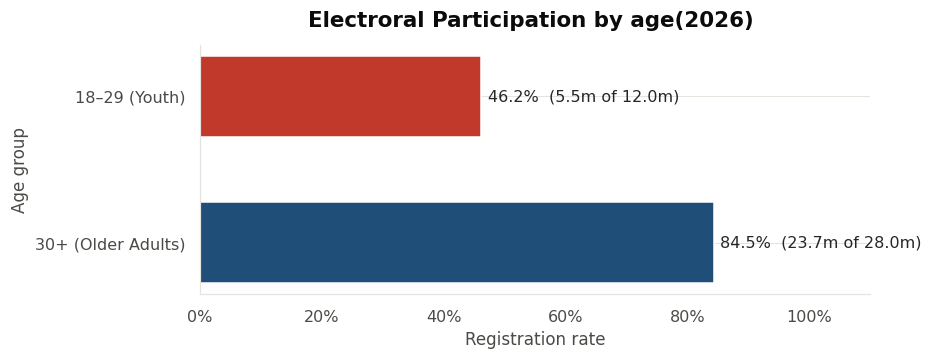

Youth rate below the 30+ rate in 212 of 213 municipalities


Age Group,Registered,Eligible (Census 2022),Registration Rate (%)
18–29 (Youth),"5,546,643","12,005,388",46.2%
30+ (Older Adults),"23,685,231","28,044,891",84.5%


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

# 1. Define the helper function if it hasn't been run yet in your notebook
def calculate_age_group_metrics(df, year=2026):
    df_yr = df[df["election"] == year]

    # Aggregating national totals for youth (18-29) vs older adults (30+)
    youth_reg = df_yr["registered_youth"].sum()
    youth_elig = df_yr["eligible_youth"].sum()

    total_reg = df_yr["registered"].sum()
    total_elig = df_yr["eligible_adults"].sum()

    older_reg = total_reg - youth_reg
    older_elig = total_elig - youth_elig

    data = [
        {"age_group": "18–29 (Youth)", "registered": youth_reg, "eligible": youth_elig},
        {"age_group": "30+ (Older Adults)", "registered": older_reg, "eligible": older_elig}
    ]

    res_df = pd.DataFrame(data)
    res_df["registration_rate_%"] = (res_df["registered"] / res_df["eligible"]) * 100
    return res_df

# 2. Compute q7 properly
q7 = calculate_age_group_metrics(clean, year=2026)
low = q7.loc[q7["registration_rate_%"].idxmin()]

# 3. Plotting the Chart
fig, ax = plt.subplots(figsize=(8.5, 3.4))
order = q7.sort_values("registration_rate_%")

bars = ax.barh(
    order["age_group"],
    order["registration_rate_%"],
    color=[HIGHLIGHT if g_ == low["age_group"] else MAIN for g_ in order["age_group"]],
    height=0.55
)

for rect, (_, r_) in zip(bars, order.iterrows()):
    ax.text(
        r_["registration_rate_%"] + 1,
        rect.get_y() + rect.get_height() / 2,
        f"{r_['registration_rate_%']:.1f}%  ({r_['registered']/1e6:.1f}m of {r_['eligible']/1e6:.1f}m)",
        va="center", fontsize=10.5
    )

ax.invert_yaxis()
ax.grid(False)
ax.grid(axis="x", alpha=0.6)
ax.set_xlim(0, 110)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlabel("Registration rate")
ax.set_ylabel("Age group")
ax.set_title("Electroral Participation by age(2026) ")


tidy(ax)
plt.tight_layout()
plt.show()

# 4. Print municipal stats check
d26 = clean[clean["election"] == 2026]
youth_rate = d26["registered_youth"] / d26["eligible_youth"]
older_rate = (d26["registered"] - d26["registered_youth"]) / (d26["eligible_adults"] - d26["eligible_youth"])
print(f"Youth rate below the 30+ rate in {(youth_rate < older_rate).sum()} of {len(d26)} municipalities")

# 5. Display Summary Table
display(
    q7[["age_group", "registered", "eligible", "registration_rate_%"]]
    .rename(columns={
        "age_group": "Age Group",
        "registered": "Registered",
        "eligible": "Eligible (Census 2022)",
        "registration_rate_%": "Registration Rate (%)"
    })
    .style.format({
        "Registered": "{:,.0f}",
        "Eligible (Census 2022)": "{:,.0f}",
        "Registration Rate (%)": "{:.1f}%"
    }).hide(axis="index")
)

**Answer.** The 18–29 (Youth) age group has the lowest electoral participation, with a registration rate of 46.2% (5.55 million registered out of 12.0 million eligible citizens), compared to 84.5% for older adults (30+).

## Q5. Which factors are linked to low turnout?

We look at how turnout, and the fall in turnout in 2021, move together with municipal characteristics.

**A link is not proof of a cause.** A pattern across municipalities cannot show why individuals do or do not vote
(the ecological fallacy). The honest version of "what contributes to low turnout" is "what is **associated** with it".

**Answer.** **No.** The 20 thinnest rolls and the 20 lowest turnouts share only **2** municipalities, and the two
measures are only weakly related (correlation **0.30**). Two municipalities with the same turnout can have opposite
problems — which is why the published turnout figure is not enough to plan a response.

saved q11_correlations


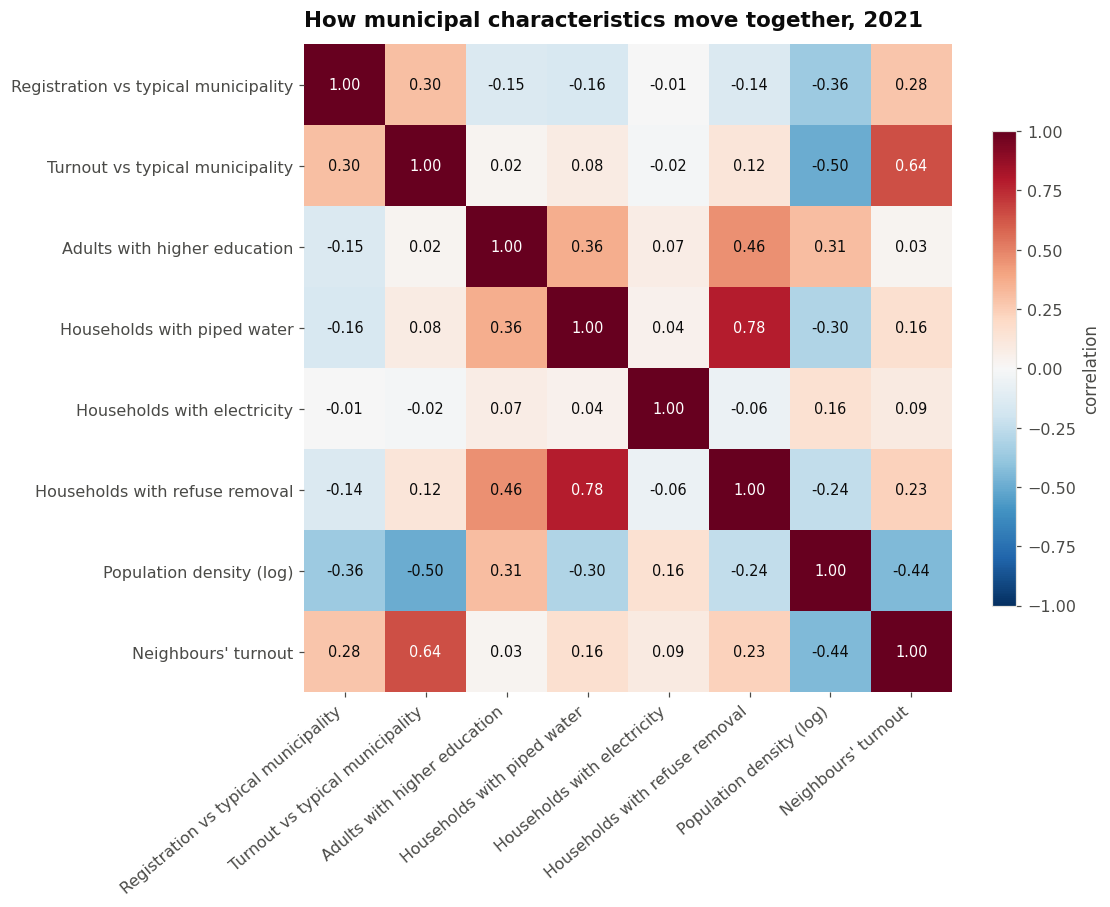

                                      Registration vs typical municipality  Turnout vs typical municipality
Registration vs typical municipality                                  1.00                             0.30
Turnout vs typical municipality                                       0.30                             1.00
Adults with higher education                                         -0.15                             0.02
Households with piped water                                          -0.16                             0.08
Households with electricity                                          -0.01                            -0.02
Households with refuse removal                                       -0.14                             0.12
Population density (log)                                             -0.36                            -0.50
Neighbours' turnout                                                   0.28                             0.64


In [ ]:
y21["log_density"] = np.log(y21["pop_density"])
feats = ["leak_reg", "leak_turn", "higher_ed_rate", "piped_water_rate", "electricity_rate",
         "refuse_removal_rate", "log_density", "spatial_lag_turnout"]
corr = y21[feats].corr()
names = [LABELS[f] for f in feats]

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(names, rotation=40, ha="right", fontsize=10.5)
ax.set_yticks(range(len(feats))); ax.set_yticklabels(names, fontsize=10.5)
for i in range(len(feats)):
    for j in range(len(feats)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9.5, color="white" if abs(v) > .55 else INK)
ax.set_title("How municipal characteristics move together, 2021")
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="correlation")
save(fig, "q11_correlations"); plt.show()

print(corr[["leak_reg", "leak_turn"]].rename(index=LABELS, columns=LABELS).round(2).to_string())

## Q6. Does low turnout cluster geographically?

saved q12_clustering


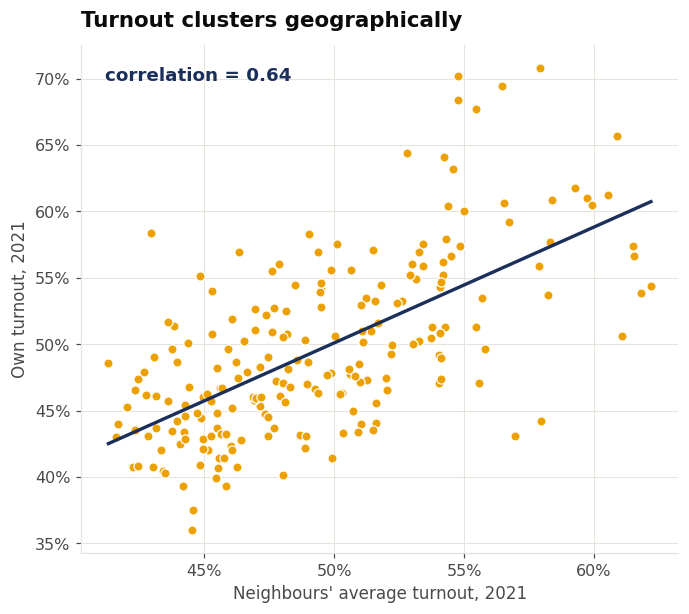

Same election: 0.64   |   neighbours' turnout at the previous election: 0.54


In [ ]:
sp = y21.dropna(subset=["spatial_lag_turnout", "t"])
rho = sp["t"].corr(sp["spatial_lag_turnout"])
rho_prev = y21["t"].corr(y21["spatial_lag_prev"]) if "spatial_lag_prev" in y21 else np.nan

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sp["spatial_lag_turnout"], sp["t"], s=36, color=AMBER, edgecolor=SURFACE, linewidth=0.8)
b, a = np.polyfit(sp["spatial_lag_turnout"], sp["t"], 1)
xs = np.linspace(sp["spatial_lag_turnout"].min(), sp["spatial_lag_turnout"].max(), 50)
ax.plot(xs, a + b * xs, color=NAVY, lw=2.2)
ax.annotate(f"correlation = {rho:.2f}", (0.04, 0.93), xycoords="axes fraction", fontsize=12, color=NAVY,
            weight="bold")
pct(ax); pct(ax, "x"); tidy(ax, xgrid=True)
ax.set_xlabel("Neighbours' average turnout, 2021"); ax.set_ylabel("Own turnout, 2021")
ax.set_title("Turnout clusters geographically")
save(fig, "q12_clustering"); plt.show()
print(f"Same election: {rho:.2f}   |   neighbours' turnout at the previous election: {rho_prev:.2f}")

**Answer.** **Yes.** A municipality's turnout is strongly related to its neighbours' turnout in the same election
(correlation **0.64**), and still clearly related to their turnout at the previous election (**0.54**). Low turnout is
regional — e.g. across parts of Limpopo, North West and Mpumalanga.

**Careful.** Clustering suggests regional causes but does not identify them. The model uses the *previous-election*
version, because when forecasting 2026 nobody's 2026 turnout is known yet.

## Q7: How does population density afffect low turnout?

Pearson Correlation: -0.497 (p-value: 0.0000)


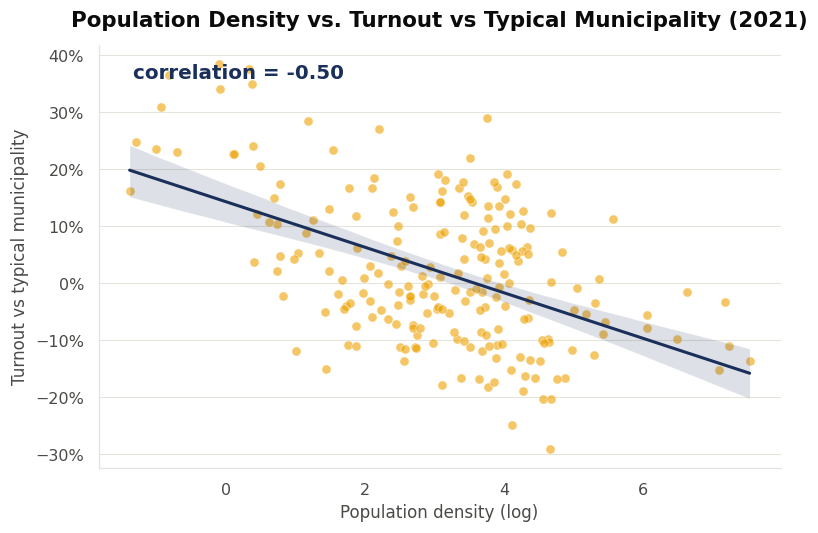

In [94]:
fig, ax = plt.subplots(figsize=(8, 5))

if "log_density" not in y21.columns:
    y21["log_density"] = np.log(y21["pop_density"])

plot_df = y21.dropna(subset=['log_density', 'leak_turn'])

corr, p_val = stats.pearsonr(plot_df['log_density'], plot_df['leak_turn'])

sns.regplot(
    data=plot_df,
    x='log_density',
    y='leak_turn',
    scatter_kws={'alpha': 0.6, 'color': AMBER, 'edgecolors': 'white', 'linewidths': 0.5},
    line_kws={'color': NAVY, 'linewidth': 2},
    ax=ax
)

ax.text(
    0.05, 0.92,
    f"correlation = {corr:.2f}",
    transform=ax.transAxes,
    fontsize=13,
    weight='bold',
    color=NAVY
)

ax.set_title("Population Density vs. Turnout vs Typical Municipality (2021)")
ax.set_xlabel(LABELS.get('log_density', 'Population density (log)'))
ax.set_ylabel(LABELS.get('leak_turn', 'Turnout vs typical municipality'))

pct(ax, axis='y')
tidy(ax)

print(f"Pearson Correlation: {corr:.3f} (p-value: {p_val:.4f})")

The Core Finding: Population density exhibits a moderate negative correlation with relative turnout performance (correlation = -0.50 against leak_turn in 2021). Densely populated metropolitan and urban areas frequently experience higher relative "turnout leaks" compared to smaller, tightly-knit municipalities.

## Q8. Where should effort go before 4 November 2026?

2026 has no turnout yet, so we combine **what we know now** (the 2026 roll) with **what happened last time** (2021
turnout), and turn each shortfall into **people**: how many more registrations, and how many more voters, would bring
the municipality up to the typical level. *(The dashboard uses the model's predicted 2026 turnout instead.)*

In [ ]:
prio = y26[["muni_code", "muni_name", "province", "leak_reg", "r", "registered", "eligible_adults"]].merge(
    y21[["muni_code", "leak_turn", "t"]], on="muni_code")
prio["group"] = group_of(prio["leak_reg"], prio["leak_turn"])
prio["shortfall"] = -(prio["leak_reg"] + prio["leak_turn"])            # bigger = further below typical
r_typ, t_typ = prio["r"].median(), prio["t"].median()
prio["registrations_needed"] = (r_typ * prio["eligible_adults"] - prio["registered"]).clip(lower=0).round(-1)
prio["extra_voters_needed"] = ((t_typ - prio["t"]) * prio["registered"]).clip(lower=0).round(-1)
prio["what_to_send"] = prio["group"].map(WHAT_TO_SEND)

top = prio.nlargest(15, "shortfall")
print(f"Below typical on both measures: {(prio.group == 'Both low').sum()} municipalities\n")
print(top[["muni_name", "province", "r", "t", "registrations_needed", "extra_voters_needed", "what_to_send"]]
      .rename(columns=LABELS | {"r": "Registration 2026", "t": "Turnout 2021",
                                "registrations_needed": "Registrations needed",
                                "extra_voters_needed": "Extra voters needed", "what_to_send": "What to send"})
      .assign(**{"Registration 2026": lambda d: (d["Registration 2026"] * 100).round(1),
                 "Turnout 2021": lambda d: (d["Turnout 2021"] * 100).round(1)})
      .to_string(index=False))

Below typical on both measures: 67 municipalities

           Municipality      Province  Registration 2026  Turnout 2021  Registrations needed  Extra voters needed                            What to send
                Mkhondo    Mpumalanga               48.8          43.1               49100.0               4060.0                   both - first priority
             Msukaligwa    Mpumalanga               57.6          40.3               28300.0               6080.0                   both - first priority
        Thembisile Hani    Mpumalanga               60.6          40.7               50610.0              12580.0                   both - first priority
               Emfuleni       Gauteng               58.2          43.7              130790.0              16780.0                   both - first priority
               Mafikeng    North West               67.8          37.6               24230.0              15950.0                   both - first priority
Dr Pixley Ka Isaka Seme  

Municipalities that suffer from both low registration and low turnout are given first priority because they face a dual-sided deficit, struggling simultaneously with low voter enrollment on the roll and poor voter turnout on election day.

Action required: They are flagged as top priority (first priority) for comprehensive interventions that tackle both challenges simultaneously (such as combining registration drives, ID/address assistance, and voter education/mobilisation).

In [ ]:
print("Figures written to", FIGURES)
for f in sorted(FIGURES.glob("*.png")):
    print(" ", f.name)

Figures written to /content/drive/MyDrive/DIRISA_SDC/reports/figures
  q01_turnout.png
  q02_turnout_by_province.png
  q03_turnout_spread.png
  q04_lowest_turnout.png
  q05_registered.png
  q06_registration_change.png
  q07_funnel.png
  q08_problem_groups.png
  q08_problem_map.png
  q09_two_leaks.png
  q10_youth.png
  q11_correlations.png
  q11_density.png
  q12_clustering.png
  q14_priority.png
  q15_registration_effort.png
